# Camouflaged Object Detection Net baseline vs. SegFormer

This notebook builds a binary segmentation pipeline that predicts a camouflaged-object
mask for a given image, using the Kaggle "Camouflaged-Object-Detection" dataset (the
standard COD10K + CAMO training pool, evaluated on the CAMO / CHAMELEON / COD10K / NC4K
test benchmarks).

**A note on scope.** This version is pushed further than earlier ones in this series full training set,
higher resolution, a larger encoder, an imbalance-weighted loss, and test-time augmentation, all in Section 2's
config because an earlier, smaller-scale run showed real headroom (both models were still improving when
training stopped) rather than because more is automatically better. Published results on this exact benchmark
still come from models trained even longer, with extra tricks like edge supervision and multi-scale training
this notebook doesn't attempt the goal here is the strongest correct, honestly-evaluated result this pipeline
can produce on a single Colab GPU session, not a leaderboard entry.

## Setup

In [1]:
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless kagglehub

import os
import re
import random
import shutil
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type != "cuda":
    print("WARNING: no GPU detected. Go to Runtime > Change runtime type > GPU before training.")


Device: cuda


## Configuration

Every knob that controls runtime vs. accuracy lives here. The defaults below are pushed further than earlier versions of this notebook, based on evidence from an actual run rather than guessing: the first real run used a 3,000-image subset at 256px with the smallest transformer encoder and both models' validation curves were still climbing when training stopped, so this version trains on the full pool at a higher resolution with a larger encoder. **This will take meaningfully longer than earlier versions** (roughly the full ~3.7x more images per epoch, ~1.3x more pixels per image, and a main model with ~3.7x more parameters) keep the Colab tab active, and don't download the notebook until the last cell has finished (see the note in the intro).

In [2]:
CONFIG = {
    # Data
    "image_size": 288,           # up from 256 (papers typically use 352-384; 288 is a middle ground that
                                  # doesn't multiply runtime as much as going all the way to 352)
    "train_subset_size": None,   # up from a 3,000-image cap: use the full ~9,900-image training split.
                                  # This is the single biggest lever available the earlier subset run was
                                  # still improving when training stopped, so more data should help directly.
    "val_fraction": 0.1,

    # Training
    "batch_size": 16,
    "num_workers": 2,
    "epochs_baseline": 18,       # an upper bound, not a target: early stopping (below) usually stops sooner
    "epochs_main": 18,
    "early_stopping_patience": 5,  # stop if validation Dice hasn't improved in this many epochs
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,

    # Models
    "baseline_encoder": "resnet18",
    "main_encoder": "mit_b1",    # up from mit_b0: SegFormer already won the model comparison in the first
                                  # real run, so it gets the extra capacity rather than splitting it evenly
    "encoder_weights": "imagenet",

    # Evaluation
    "threshold": 0.5,
    "use_tta": True,             # average a prediction with its horizontal-flip prediction at evaluation
                                  # time (not during per-epoch training validation, to keep training fast)
}
print(CONFIG)


{'image_size': 288, 'train_subset_size': None, 'val_fraction': 0.1, 'batch_size': 16, 'num_workers': 2, 'epochs_baseline': 18, 'epochs_main': 18, 'early_stopping_patience': 5, 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'baseline_encoder': 'resnet18', 'main_encoder': 'mit_b1', 'encoder_weights': 'imagenet', 'threshold': 0.5, 'use_tta': True}


## Load the dataset

Tries `kagglehub` first, falls back to a manual upload, and finally to a local path if you've already extracted the dataset somewhere. **The exact Kaggle slug below is inferred from the dataset page and may need correcting** if `kagglehub` fails, copy the correct slug from the dataset's Kaggle URL (`kaggle.com/datasets/<slug>`) and paste it into `KAGGLE_SLUG`.

In [3]:
KAGGLE_SLUG = "reo998/camouflaged-object-detection"
DATA_ROOT = None

try:
    import kagglehub
    DATA_ROOT = kagglehub.dataset_download(KAGGLE_SLUG)
    print("Downloaded via kagglehub to:", DATA_ROOT)
except Exception as e:
    print(f"kagglehub download failed ({e}).")
    print("Falling back to manual upload / local path options below.")


Using Colab cache for faster access to the 'camouflaged-object-detection' dataset.
Downloaded via kagglehub to: /kaggle/input/camouflaged-object-detection


In [4]:
# Fallback 1: manual upload (only runs if the kagglehub cell above didn't set DATA_ROOT).
# In Colab this will prompt a file picker for a .zip export of the dataset.
if DATA_ROOT is None:
    try:
        from google.colab import files
        print("Upload the dataset .zip (or skip this cell if running locally / already extracted).")
        uploaded = files.upload()
        for fname in uploaded:
            if fname.endswith(".zip"):
                extract_dir = "/content/camo_data"
                shutil.unpack_archive(fname, extract_dir)
                DATA_ROOT = extract_dir
                print("Extracted to:", DATA_ROOT)
    except ImportError:
        pass  # not running in Colab

# Fallback 2: point this at a local extraction if you already have one.
if DATA_ROOT is None:
    LOCAL_FALLBACK = "./camouflaged-object-detection"
    if os.path.isdir(LOCAL_FALLBACK):
        DATA_ROOT = LOCAL_FALLBACK

assert DATA_ROOT is not None, "Could not locate the dataset. Set DATA_ROOT manually to the extracted folder."
print("Using DATA_ROOT:", DATA_ROOT)


Using DATA_ROOT: /kaggle/input/camouflaged-object-detection


## Find the folder structure

Kaggle re-packagings of this benchmark don't always use identical folder names, so this searches for the expected structure instead of hard-coding it, and prints what it finds.

In [5]:
IMG_DIR_NAMES = {"imgs", "images", "image", "im", "jpegimages"}
MASK_DIR_NAMES = {"gt", "gts", "mask", "masks", "groundtruth", "ground_truth", "annotation", "annotations"}
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp")


def find_dir_by_name(root, target_names):
    '''Return every directory under root whose basename matches one of target_names (case-insensitive).'''
    matches = []
    for dirpath, dirnames, _ in os.walk(root):
        if os.path.basename(dirpath).lower() in target_names:
            matches.append(dirpath)
    return matches


def find_top_dir(root, target_name):
    for dirpath, dirnames, _ in os.walk(root):
        if os.path.basename(dirpath).lower() == target_name:
            return dirpath
    return None


train_root = find_top_dir(DATA_ROOT, "traindataset")
test_root = find_top_dir(DATA_ROOT, "testdataset")

assert train_root is not None, f"Could not find a 'TrainDataset' folder under {DATA_ROOT}"
assert test_root is not None, f"Could not find a 'TestDataset' folder under {DATA_ROOT}"

test_subsets = sorted([d for d in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, d))])
print("Train folder: ", train_root)
print("Test folder:  ", test_root)
print("Test subsets found:", test_subsets)


Train folder:  /kaggle/input/camouflaged-object-detection/input/train-dataset-cod/TrainDataset
Test folder:   /kaggle/input/camouflaged-object-detection/input/test-dataset-cod/TestDataset
Test subsets found: ['CAMO', 'CHAMELEON', 'COD10K', 'NC4K']


##  Pair every image with its mask

For a folder containing an image directory and a mask directory, match files by filename stem and report anything that didn't match on either side rather than silently dropping it.

In [6]:
def pair_images_and_masks(base_dir, label=""):
    img_dirs = find_dir_by_name(base_dir, IMG_DIR_NAMES)
    mask_dirs = find_dir_by_name(base_dir, MASK_DIR_NAMES)
    if not img_dirs or not mask_dirs:
        raise FileNotFoundError(f"Could not find image/mask subfolders under {base_dir}")

    # if more than one candidate exists, take the one with the most files
    img_dir = max(img_dirs, key=lambda d: len(os.listdir(d)))
    mask_dir = max(mask_dirs, key=lambda d: len(os.listdir(d)))

    img_files = {Path(f).stem: os.path.join(img_dir, f)
                 for f in os.listdir(img_dir) if f.lower().endswith(IMAGE_EXTS)}
    mask_files = {Path(f).stem: os.path.join(mask_dir, f)
                  for f in os.listdir(mask_dir) if f.lower().endswith(IMAGE_EXTS)}

    common = sorted(set(img_files) & set(mask_files))
    pairs = [(img_files[k], mask_files[k]) for k in common]

    n_img_only = len(set(img_files) - set(mask_files))
    n_mask_only = len(set(mask_files) - set(img_files))
    print(f"[{label}] images={len(img_files)} masks={len(mask_files)} "
          f"matched={len(pairs)} image-only={n_img_only} mask-only={n_mask_only}")
    return pairs


train_pairs_all = pair_images_and_masks(train_root, label="train")

test_pairs_by_subset = {}
for subset in test_subsets:
    test_pairs_by_subset[subset] = pair_images_and_masks(os.path.join(test_root, subset), label=subset)

total_test = sum(len(v) for v in test_pairs_by_subset.values())
print(f"\nTotal matched training pairs: {len(train_pairs_all)}")
print(f"Total matched test pairs (all subsets): {total_test}")


[train] images=11000 masks=11250 matched=11000 image-only=0 mask-only=250
[CAMO] images=250 masks=250 matched=250 image-only=0 mask-only=0
[CHAMELEON] images=76 masks=76 matched=76 image-only=0 mask-only=0
[COD10K] images=2026 masks=2026 matched=2026 image-only=0 mask-only=0
[NC4K] images=4121 masks=4121 matched=4121 image-only=0 mask-only=0

Total matched training pairs: 11000
Total matched test pairs (all subsets): 6473


## A quick look at the data

Image sizes vary (typical of a benchmark assembled from multiple sources), and camouflaged objects tend to cover a small fraction of the image both of which motivate resizing consistently, using a loss (Dice) that doesn't get dominated by the background class, and new in this version measuring that imbalance directly and feeding it into BCE's `pos_weight` (Section 9) instead of leaving BCE to treat every pixel as equally important.

Sampled 300 training pairs
Height: min=168 median=649 max=1389
Width:  min=183 median=800 max=1800
Camouflaged-object coverage of image area: mean=5.7% median=1.8% max=74.9%
Estimated foreground fraction: 5.7%  ->  BCE pos_weight=16.42


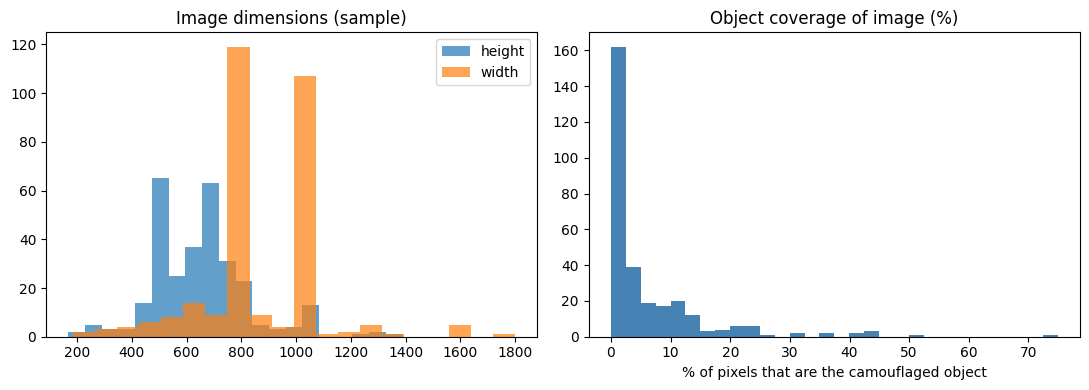

In [7]:
sample_n = min(300, len(train_pairs_all))
sample_pairs = random.sample(train_pairs_all, sample_n)

sizes = []
coverage = []
for img_path, mask_path in sample_pairs:
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img is None or mask is None:
        continue
    sizes.append(img.shape[:2])
    coverage.append((mask > 127).mean())

sizes = np.array(sizes)
coverage = np.array(coverage)

print(f"Sampled {len(sizes)} training pairs")
print(f"Height: min={sizes[:,0].min()} median={int(np.median(sizes[:,0]))} max={sizes[:,0].max()}")
print(f"Width:  min={sizes[:,1].min()} median={int(np.median(sizes[:,1]))} max={sizes[:,1].max()}")
print(f"Camouflaged-object coverage of image area: "
      f"mean={coverage.mean():.1%} median={np.median(coverage):.1%} max={coverage.max():.1%}")

# The object is a small minority of pixels in most images, so plain BCE would mostly be graded on
# getting the (easy, majority) background right. Weighting positive (object) pixels by the measured
# imbalance gives the loss a reason to care about getting the object right too.
foreground_fraction = float(coverage.mean())
pos_weight_value = float(np.clip((1 - foreground_fraction) / (foreground_fraction + 1e-6), 1.0, 20.0))
POS_WEIGHT = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
print(f"Estimated foreground fraction: {foreground_fraction:.1%}  ->  BCE pos_weight={pos_weight_value:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sizes[:, 0], bins=20, alpha=0.7, label="height")
axes[0].hist(sizes[:, 1], bins=20, alpha=0.7, label="width")
axes[0].set_title("Image dimensions (sample)")
axes[0].legend()
axes[1].hist(coverage * 100, bins=30, color="steelblue")
axes[1].set_title("Object coverage of image (%)")
axes[1].set_xlabel("% of pixels that are the camouflaged object")
plt.tight_layout()
plt.show()


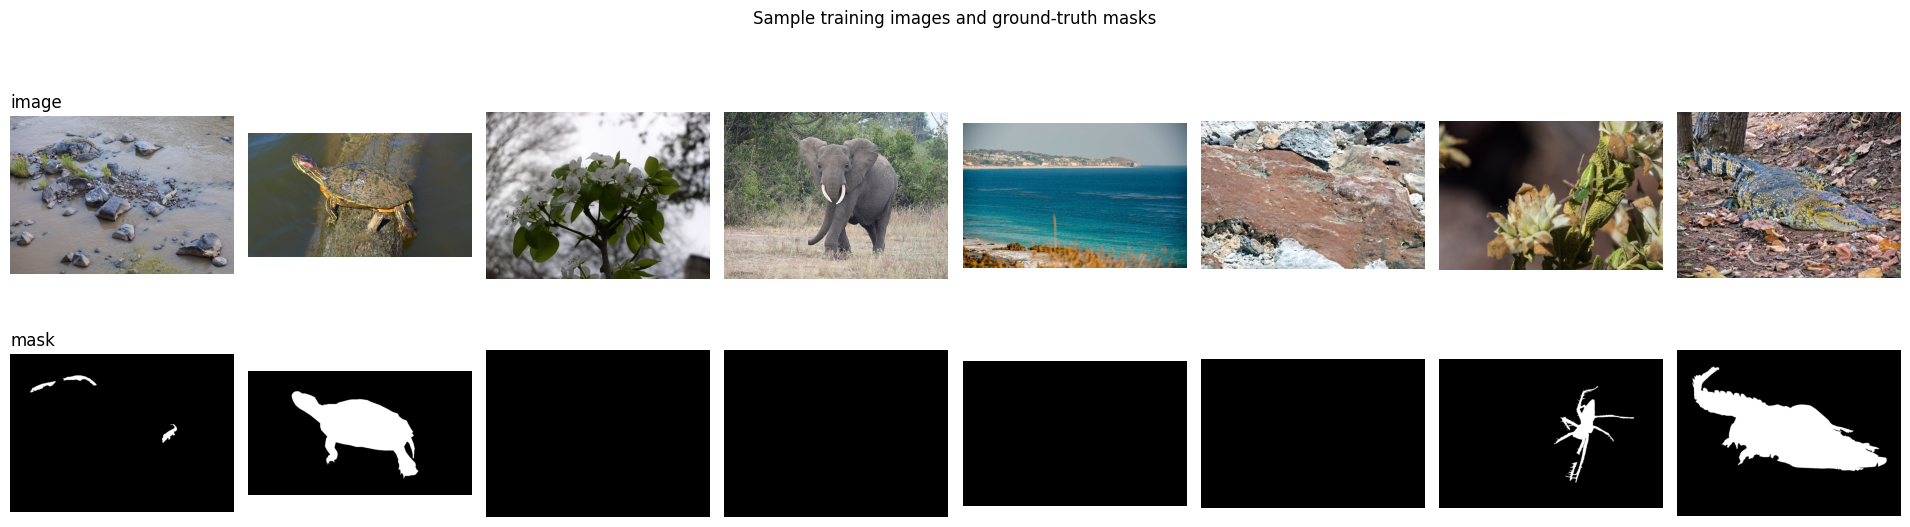

In [8]:
N_EDA_SAMPLES = 8
fig, axes = plt.subplots(2, N_EDA_SAMPLES, figsize=(2.4 * N_EDA_SAMPLES, 6))
for i, (img_path, mask_path) in enumerate(random.sample(train_pairs_all, N_EDA_SAMPLES)):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    axes[0, i].imshow(img); axes[0, i].axis("off")
    axes[1, i].imshow(mask, cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("image", loc="left")
axes[1, 0].set_title("mask", loc="left")
fig.suptitle("Sample training images and ground-truth masks")
plt.tight_layout()
plt.show()


## Train / validation split

The training pool is randomly split, since it's already a single combined set (COD10K + CAMO training images) rather than several distinct distributions. The four benchmark test sets stay completely separate and untouched until the test evaluation later on.

In [9]:
pairs_for_training = train_pairs_all
if CONFIG["train_subset_size"] is not None and len(pairs_for_training) > CONFIG["train_subset_size"]:
    random.shuffle(pairs_for_training)
    pairs_for_training = pairs_for_training[: CONFIG["train_subset_size"]]
    print(f"Using a subset of {len(pairs_for_training)} / {len(train_pairs_all)} training pairs "
          f"(set CONFIG['train_subset_size'] = None to use all of them).")

random.shuffle(pairs_for_training)
n_val = max(1, int(len(pairs_for_training) * CONFIG["val_fraction"]))
val_pairs = pairs_for_training[:n_val]
train_pairs = pairs_for_training[n_val:]
print(f"Train: {len(train_pairs)}  Val: {len(val_pairs)}")


Train: 9900  Val: 1100


## Dataset, augmentation, and dataloaders

Augmentation is deliberately conservative flips, mild rotation, and color jitter since camouflage depends on subtle texture/color relationships that heavier augmentation could destroy. Masks are resized with nearest-neighbor interpolation so resizing never invents soft gray boundary values.

In [20]:
IMG_SIZE = CONFIG["image_size"]
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
              mask_interpolation=cv2.INTER_NEAREST, p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
], is_check_shapes=False)

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
], is_check_shapes=False)


class CODDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype("float32")

        augmented = self.transform(image=image, mask=mask)
        image = augmented["image"]
        mask = augmented["mask"].float().unsqueeze(0)  # -> (1, H, W)
        return image, mask


train_ds = CODDataset(train_pairs, train_transform)
val_ds = CODDataset(val_pairs, eval_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)

# sanity check on shapes before training anything
xb, yb = next(iter(train_loader))
print("Image batch:", xb.shape, xb.dtype, " Mask batch:", yb.shape, yb.dtype)
assert xb.shape[1:] == (3, IMG_SIZE, IMG_SIZE)
assert yb.shape[1:] == (1, IMG_SIZE, IMG_SIZE)
assert set(torch.unique(yb).tolist()) <= {0.0, 1.0}

Image batch: torch.Size([16, 3, 288, 288]) torch.float32  Mask batch: torch.Size([16, 1, 288, 288]) torch.float32


## Loss and metrics

`BCEWithLogitsLoss` handles per-pixel classification, now weighted by the `pos_weight` measured in Section 6 so missing the (minority) object is penalized proportionally to how rare it is; Dice loss is added on top because BCE alone, even weighted, tends to under-penalize missing a small object entirely. All five metrics are computed at inference threshold 0.5 by default (Section 15 tunes this per model), except MAE which is computed on the raw probability map, matching how they're reported in the segmentation literature.

In [11]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).reshape(logits.size(0), -1)
        targets = targets.reshape(targets.size(0), -1)
        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, pos_weight=None):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)


@torch.no_grad()
def compute_metrics(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = targets.float()

    dims = tuple(range(1, preds.dim()))
    intersection = (preds * targets).sum(dim=dims)
    pred_sum = preds.sum(dim=dims)
    target_sum = targets.sum(dim=dims)
    union = pred_sum + target_sum - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred_sum + target_sum + eps)

    tp = intersection
    fp = pred_sum - intersection
    fn = target_sum - intersection
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    mae = (probs - targets).abs().mean(dim=dims)

    return {
        "iou": iou.mean().item(),
        "dice": dice.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item(),
        "mae": mae.mean().item(),
    }


## Model builders

The main model requests `segmentation_models_pytorch`'s SegFormer decoder over a MiT-b0 (Mix Transformer) encoder the architecture the pasted plan asked for. `segmentation_models_pytorch` has changed its supported architectures across versions, so this falls back to a U-Net with the same transformer encoder if `smp.Segformer` isn't available in whatever version ends up installed, rather than failing outright.

In [12]:
def build_baseline_model():
    return smp.Unet(
        encoder_name=CONFIG["baseline_encoder"],
        encoder_weights=CONFIG["encoder_weights"],
        in_channels=3,
        classes=1,
    )


def build_main_model():
    if hasattr(smp, "Segformer"):
        return smp.Segformer(
            encoder_name=CONFIG["main_encoder"],
            encoder_weights=CONFIG["encoder_weights"],
            in_channels=3,
            classes=1,
        ), "Segformer"
    else:
        print("smp.Segformer not available in this segmentation_models_pytorch version; "
              "falling back to a U-Net with the same transformer encoder.")
        return smp.Unet(
            encoder_name=CONFIG["main_encoder"],
            encoder_weights=CONFIG["encoder_weights"],
            in_channels=3,
            classes=1,
        ), "Unet (mit_b0 encoder)"


baseline_model = build_baseline_model().to(DEVICE)
main_model, main_arch_name = build_main_model()
main_model = main_model.to(DEVICE)

print(f"Baseline: U-Net ({CONFIG['baseline_encoder']} encoder)")
print(f"Main model: {main_arch_name} ({CONFIG['main_encoder']} encoder)")

n_params_baseline = sum(p.numel() for p in baseline_model.parameters())
n_params_main = sum(p.numel() for p in main_model.parameters())
print(f"Baseline params: {n_params_baseline:,}")
print(f"Main model params: {n_params_main:,}")


Baseline: U-Net (resnet18 encoder)
Main model: Segformer (mit_b1 encoder)
Baseline params: 14,328,209
Main model params: 13,677,505


## 1Training loop

One generic function trains either model with AdamW, a cosine learning-rate schedule, mixed precision (only active on GPU), and the imbalance-weighted loss from Section It tracks validation Dice each epoch, keeps the best-scoring weights (the last epoch isn't always the best one), and stops early if validation Dice hasn't improved in `early_stopping_patience` epochs `epochs_baseline`/`epochs_main` are an upper bound, not a target, which also shortens a run that's already converged instead of grinding through unnecessary epochs. The best weights are checkpointed to disk **every time they improve**, not just once at the end a real run in this series was previously downloaded mid-training and lost everything past that point, so the checkpoint on disk is now never more than one improvement behind, even if the connection drops before training finishes.

In [13]:
def train_model(model, name, epochs, train_loader, val_loader, patience=None):
    if patience is None:
        patience = CONFIG["early_stopping_patience"]

    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"],
                                   weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = BCEDiceLoss(pos_weight=POS_WEIGHT)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler(enabled=use_amp)
    checkpoint_path = f"{name.lower().replace(' ', '_').replace('(', '').replace(')', '')}_best.pt"

    history = []
    best_dice = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast(device_type=DEVICE.type, enabled=use_amp):
                logits = model(images)
                loss = loss_fn(logits, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        scheduler.step()

        model.eval()
        val_loss = 0.0
        metric_totals = {"iou": 0.0, "dice": 0.0, "precision": 0.0, "recall": 0.0, "mae": 0.0}
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                logits = model(images)
                loss = loss_fn(logits, masks)
                val_loss += loss.item() * images.size(0)
                batch_metrics = compute_metrics(logits, masks, threshold=CONFIG["threshold"])
                for k in metric_totals:
                    metric_totals[k] += batch_metrics[k] * images.size(0)
        val_loss /= len(val_loader.dataset)
        for k in metric_totals:
            metric_totals[k] /= len(val_loader.dataset)

        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, **metric_totals})
        print(f"[{name}] epoch {epoch:02d}/{epochs} "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
              f"val_iou={metric_totals['iou']:.4f} val_dice={metric_totals['dice']:.4f}")

        if metric_totals["dice"] > best_dice:
            best_dice = metric_totals["dice"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, checkpoint_path)  # save on every improvement, not just at the end
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{name}] no improvement in {patience} epochs, stopping early "
                      f"at epoch {epoch}/{epochs} (best val Dice={best_dice:.4f})")
                break

    model.load_state_dict(best_state)
    print(f"[{name}] best weights (val Dice={best_dice:.4f}) saved to {checkpoint_path}")
    return model, pd.DataFrame(history)


## Train the baseline (U-Net)

In [14]:
baseline_model, baseline_history = train_model(
    baseline_model, "U-Net baseline", CONFIG["epochs_baseline"], train_loader, val_loader
)


[U-Net baseline] epoch 01/18 train_loss=1.6465 val_loss=1.5989 val_iou=0.2026 val_dice=0.2696
[U-Net baseline] epoch 02/18 train_loss=1.5310 val_loss=1.5825 val_iou=0.1964 val_dice=0.2676
[U-Net baseline] epoch 03/18 train_loss=1.4467 val_loss=1.5084 val_iou=0.2794 val_dice=0.3506
[U-Net baseline] epoch 04/18 train_loss=1.4049 val_loss=1.5135 val_iou=0.2737 val_dice=0.3420
[U-Net baseline] epoch 05/18 train_loss=1.3526 val_loss=1.4288 val_iou=0.3378 val_dice=0.4069
[U-Net baseline] epoch 06/18 train_loss=1.3054 val_loss=1.4815 val_iou=0.3417 val_dice=0.4115
[U-Net baseline] epoch 07/18 train_loss=1.2725 val_loss=1.4691 val_iou=0.3409 val_dice=0.4105
[U-Net baseline] epoch 08/18 train_loss=1.1917 val_loss=1.4939 val_iou=0.3494 val_dice=0.4161
[U-Net baseline] epoch 09/18 train_loss=1.1629 val_loss=1.4851 val_iou=0.3200 val_dice=0.3920
[U-Net baseline] epoch 10/18 train_loss=1.1371 val_loss=1.4677 val_iou=0.3457 val_dice=0.4171
[U-Net baseline] epoch 11/18 train_loss=1.1328 val_loss=1.68

## Train the main model (SegFormer)

In [15]:
main_model, main_history = train_model(
    main_model, main_arch_name, CONFIG["epochs_main"], train_loader, val_loader
)


[Segformer] epoch 01/18 train_loss=1.6178 val_loss=1.4830 val_iou=0.1993 val_dice=0.2657
[Segformer] epoch 02/18 train_loss=1.4611 val_loss=1.4374 val_iou=0.2570 val_dice=0.3242
[Segformer] epoch 03/18 train_loss=1.3726 val_loss=1.4361 val_iou=0.2726 val_dice=0.3443
[Segformer] epoch 04/18 train_loss=1.3275 val_loss=1.3539 val_iou=0.3165 val_dice=0.3876
[Segformer] epoch 05/18 train_loss=1.2742 val_loss=1.3997 val_iou=0.2408 val_dice=0.3122
[Segformer] epoch 06/18 train_loss=1.4126 val_loss=1.4781 val_iou=0.2322 val_dice=0.3050
[Segformer] epoch 07/18 train_loss=1.2826 val_loss=2.2381 val_iou=0.5163 val_dice=0.5804
[Segformer] epoch 08/18 train_loss=1.2984 val_loss=1.4006 val_iou=0.2990 val_dice=0.3700
[Segformer] epoch 09/18 train_loss=1.2586 val_loss=1.5431 val_iou=0.2364 val_dice=0.3082
[Segformer] epoch 10/18 train_loss=1.2323 val_loss=1.3974 val_iou=0.2820 val_dice=0.3539
[Segformer] epoch 11/18 train_loss=1.1463 val_loss=1.3146 val_iou=0.3093 val_dice=0.3807
[Segformer] epoch 12/

## Training curves

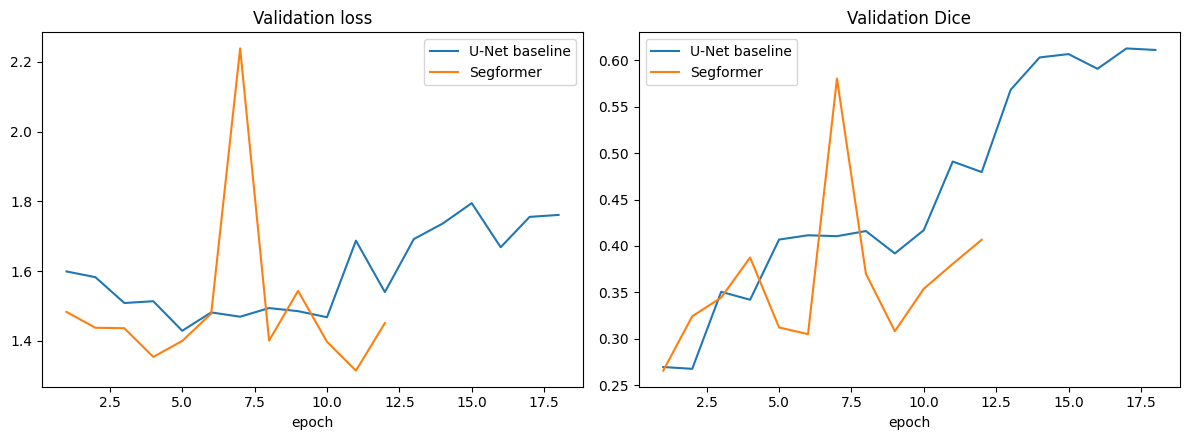

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(baseline_history["epoch"], baseline_history["val_loss"], label="U-Net baseline")
axes[0].plot(main_history["epoch"], main_history["val_loss"], label=main_arch_name)
axes[0].set_title("Validation loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(baseline_history["epoch"], baseline_history["dice"], label="U-Net baseline")
axes[1].plot(main_history["epoch"], main_history["dice"], label=main_arch_name)
axes[1].set_title("Validation Dice"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## 1 Test-time augmentation, then threshold tuning

**TTA:** averaging a model's prediction on an image with its prediction on the horizontally-flipped image (flipped back before averaging) is a well-known, essentially free way to reduce prediction noise at inference time it's applied from here on at every evaluation step, but deliberately *not* during the per-epoch training validation above, so training itself stays fast.

**Threshold tuning:** 0.5 is a reasonable default but isn't necessarily optimal for either model one model might produce systematically higher or lower probabilities than the other. This sweeps a small grid of thresholds on the (TTA-averaged) validation predictions and keeps whichever maximizes Dice for each model separately, the same idea as the decision-threshold tuning used for the fraud-detection classifier earlier in this series, applied here to a segmentation cutoff instead of a classification one.

U-Net baseline : best threshold=0.70  (val Dice=0.6482, vs. 0.50 default)
Segformer      : best threshold=0.70  (val Dice=0.6262, vs. 0.50 default)


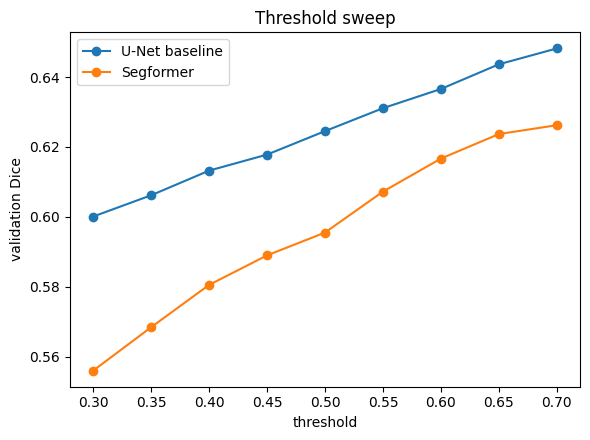

In [17]:
@torch.no_grad()
def predict_logits(model, images, tta=None):
    if tta is None:
        tta = CONFIG["use_tta"]
    logits = model(images)
    if tta:
        flipped_logits = model(torch.flip(images, dims=[3]))
        logits = (logits + torch.flip(flipped_logits, dims=[3])) / 2
    return logits


@torch.no_grad()
def tune_threshold(model, loader, thresholds=np.arange(0.30, 0.71, 0.05)):
    model.eval()
    best_t, best_dice = 0.5, -1.0
    curve = []
    for t in thresholds:
        dice_total, n = 0.0, 0
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = predict_logits(model, images)
            m = compute_metrics(logits, masks, threshold=t)
            dice_total += m["dice"] * images.size(0)
            n += images.size(0)
        dice = dice_total / n
        curve.append((t, dice))
        if dice > best_dice:
            best_dice, best_t = dice, t
    return best_t, best_dice, curve


baseline_best_t, baseline_best_dice, baseline_t_curve = tune_threshold(baseline_model, val_loader)
main_best_t, main_best_dice, main_t_curve = tune_threshold(main_model, val_loader)

best_thresholds = {"U-Net baseline": baseline_best_t, main_arch_name: main_best_t}

print(f"U-Net baseline : best threshold={baseline_best_t:.2f}  (val Dice={baseline_best_dice:.4f}, "
      f"vs. {CONFIG['threshold']:.2f} default)")
print(f"{main_arch_name:<15}: best threshold={main_best_t:.2f}  (val Dice={main_best_dice:.4f}, "
      f"vs. {CONFIG['threshold']:.2f} default)")

plt.figure(figsize=(6, 4.5))
plt.plot(*zip(*baseline_t_curve), marker="o", label="U-Net baseline")
plt.plot(*zip(*main_t_curve), marker="o", label=main_arch_name)
plt.xlabel("threshold"); plt.ylabel("validation Dice"); plt.title("Threshold sweep")
plt.legend()
plt.tight_layout()
plt.show()


## 1Model comparison on the validation set

Same five metrics for both models, each evaluated with TTA at its own tuned threshold from Section 15, so the SegFormer/U-Net choice below is based on a number rather than an assumption that the newer architecture must be better.

In [18]:
@torch.no_grad()
def evaluate(model, loader, threshold):
    model.eval()
    totals = {"iou": 0.0, "dice": 0.0, "precision": 0.0, "recall": 0.0, "mae": 0.0}
    n = 0
    for images, masks in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = predict_logits(model, images)
        batch_metrics = compute_metrics(logits, masks, threshold=threshold)
        bs = images.size(0)
        for k in totals:
            totals[k] += batch_metrics[k] * bs
        n += bs
    return {k: v / n for k, v in totals.items()}


val_results = pd.DataFrame([
    {"model": "U-Net baseline", "threshold": best_thresholds["U-Net baseline"],
     **evaluate(baseline_model, val_loader, best_thresholds["U-Net baseline"])},
    {"model": main_arch_name, "threshold": best_thresholds[main_arch_name],
     **evaluate(main_model, val_loader, best_thresholds[main_arch_name])},
]).sort_values("dice", ascending=False).reset_index(drop=True)

print(val_results.to_string(index=False))

best_model_name = val_results.iloc[0]["model"]
best_model = main_model if best_model_name == main_arch_name else baseline_model
best_threshold = best_thresholds[best_model_name]
print(f"\nSelected for final evaluation: {best_model_name} (threshold={best_threshold:.2f})")


         model  threshold      iou     dice  precision   recall      mae
U-Net baseline        0.7 0.580178 0.648176   0.667556 0.833189 0.076251
     Segformer        0.7 0.566538 0.626230   0.734390 0.744422 0.087754

Selected for final evaluation: U-Net baseline (threshold=0.70)


## 1Evaluate on each test benchmark

CAMO, CHAMELEON, COD10K, and NC4K were built from different image sources and vary in difficulty, so a single pooled score can hide a model that's much weaker on one of them. Reporting each separately (plus an overall pooled row) is how this is normally done in the literature.

In [21]:
test_rows = []
all_test_pairs = []
for subset, pairs in test_pairs_by_subset.items():
    if len(pairs) == 0:
        continue
    loader = DataLoader(CODDataset(pairs, eval_transform), batch_size=CONFIG["batch_size"],
                         shuffle=False, num_workers=CONFIG["num_workers"])
    metrics = evaluate(best_model, loader, best_threshold)
    test_rows.append({"benchmark": subset, "n_images": len(pairs), **metrics})
    all_test_pairs.extend(pairs)

overall_loader = DataLoader(CODDataset(all_test_pairs, eval_transform), batch_size=CONFIG["batch_size"],
                             shuffle=False, num_workers=CONFIG["num_workers"])
overall_metrics = evaluate(best_model, overall_loader, best_threshold)
test_rows.append({"benchmark": "ALL (pooled)", "n_images": len(all_test_pairs), **overall_metrics})

test_results = pd.DataFrame(test_rows)
print(test_results.to_string(index=False))


   benchmark  n_images      iou     dice  precision   recall      mae
        CAMO       250 0.468977 0.584334   0.679740 0.682167 0.160979
   CHAMELEON        76 0.601973 0.725580   0.640253 0.887948 0.108949
      COD10K      2026 0.508604 0.630498   0.583499 0.824567 0.096745
        NC4K      4121 0.522094 0.637586   0.698628 0.734850 0.121456
ALL (pooled)      6473 0.516758 0.634344   0.661179 0.762694 0.115101


## Qualitative results: best, typical, and worst predictions

Ranking every test image by IoU and looking at more than a handful of examples including a slice from the *middle* of the ranking, not just the two extremes gives a fuller picture than a cherry-picked best/worst pair would. Each row now also shows an overlay (predicted mask painted over the original image) alongside the raw probability map, since that's closer to how a result like this would actually be presented.

**A note on what shows up in the worst-N grid.** This dataset's `COD10K` split includes a `Human` category of body-painting photography a person painted to blend into flowers, wood grain, wallpaper patterns, or similar which is about as close to a worst-case camouflage as exists, deliberately designed to fool even a human viewer at a glance. It's normal, not a sign of a regression, for several of these to show up with IoU near 0 in the bottom-N ranking, especially once N is raised from 3 to 6 and reaches further into the tail of genuinely hardest images. What would actually be a red flag is an *ordinary* animal-in-foliage photo scoring near 0 that's the case worth investigating if it comes up.

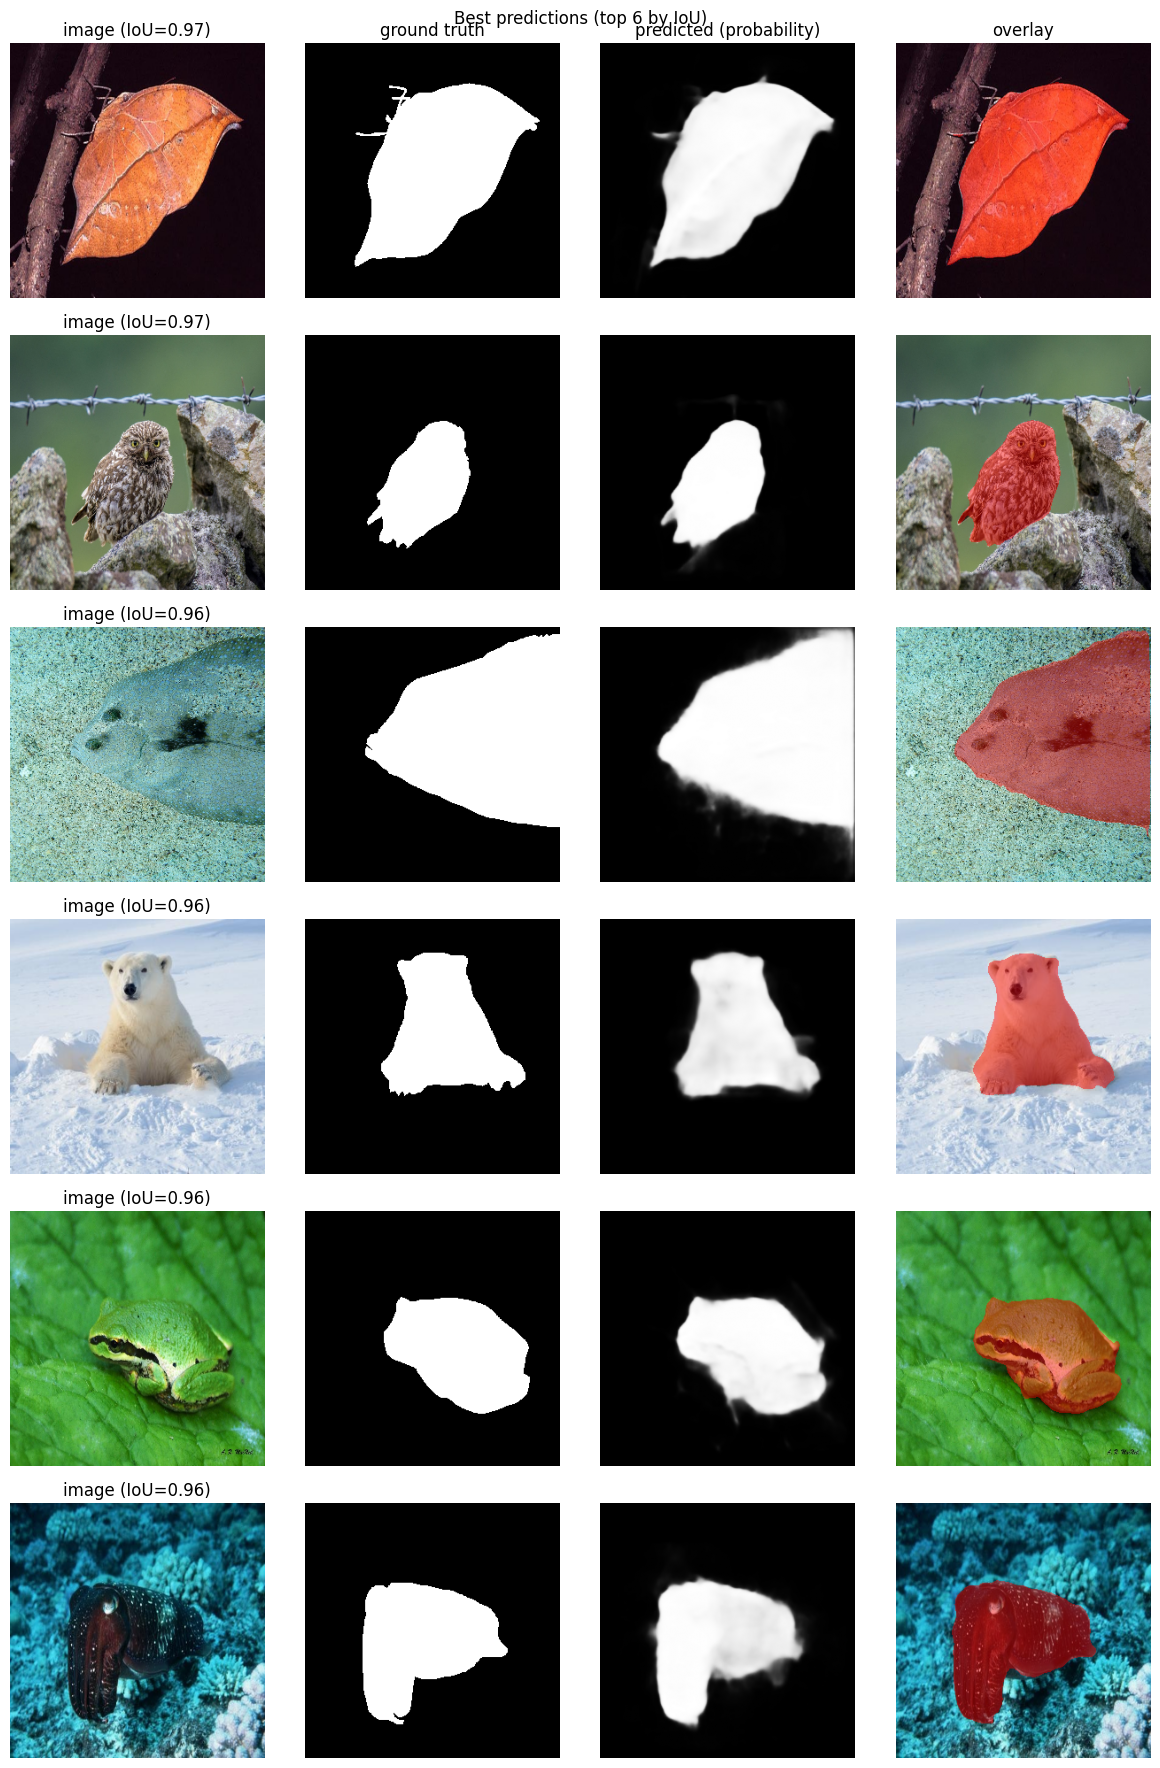

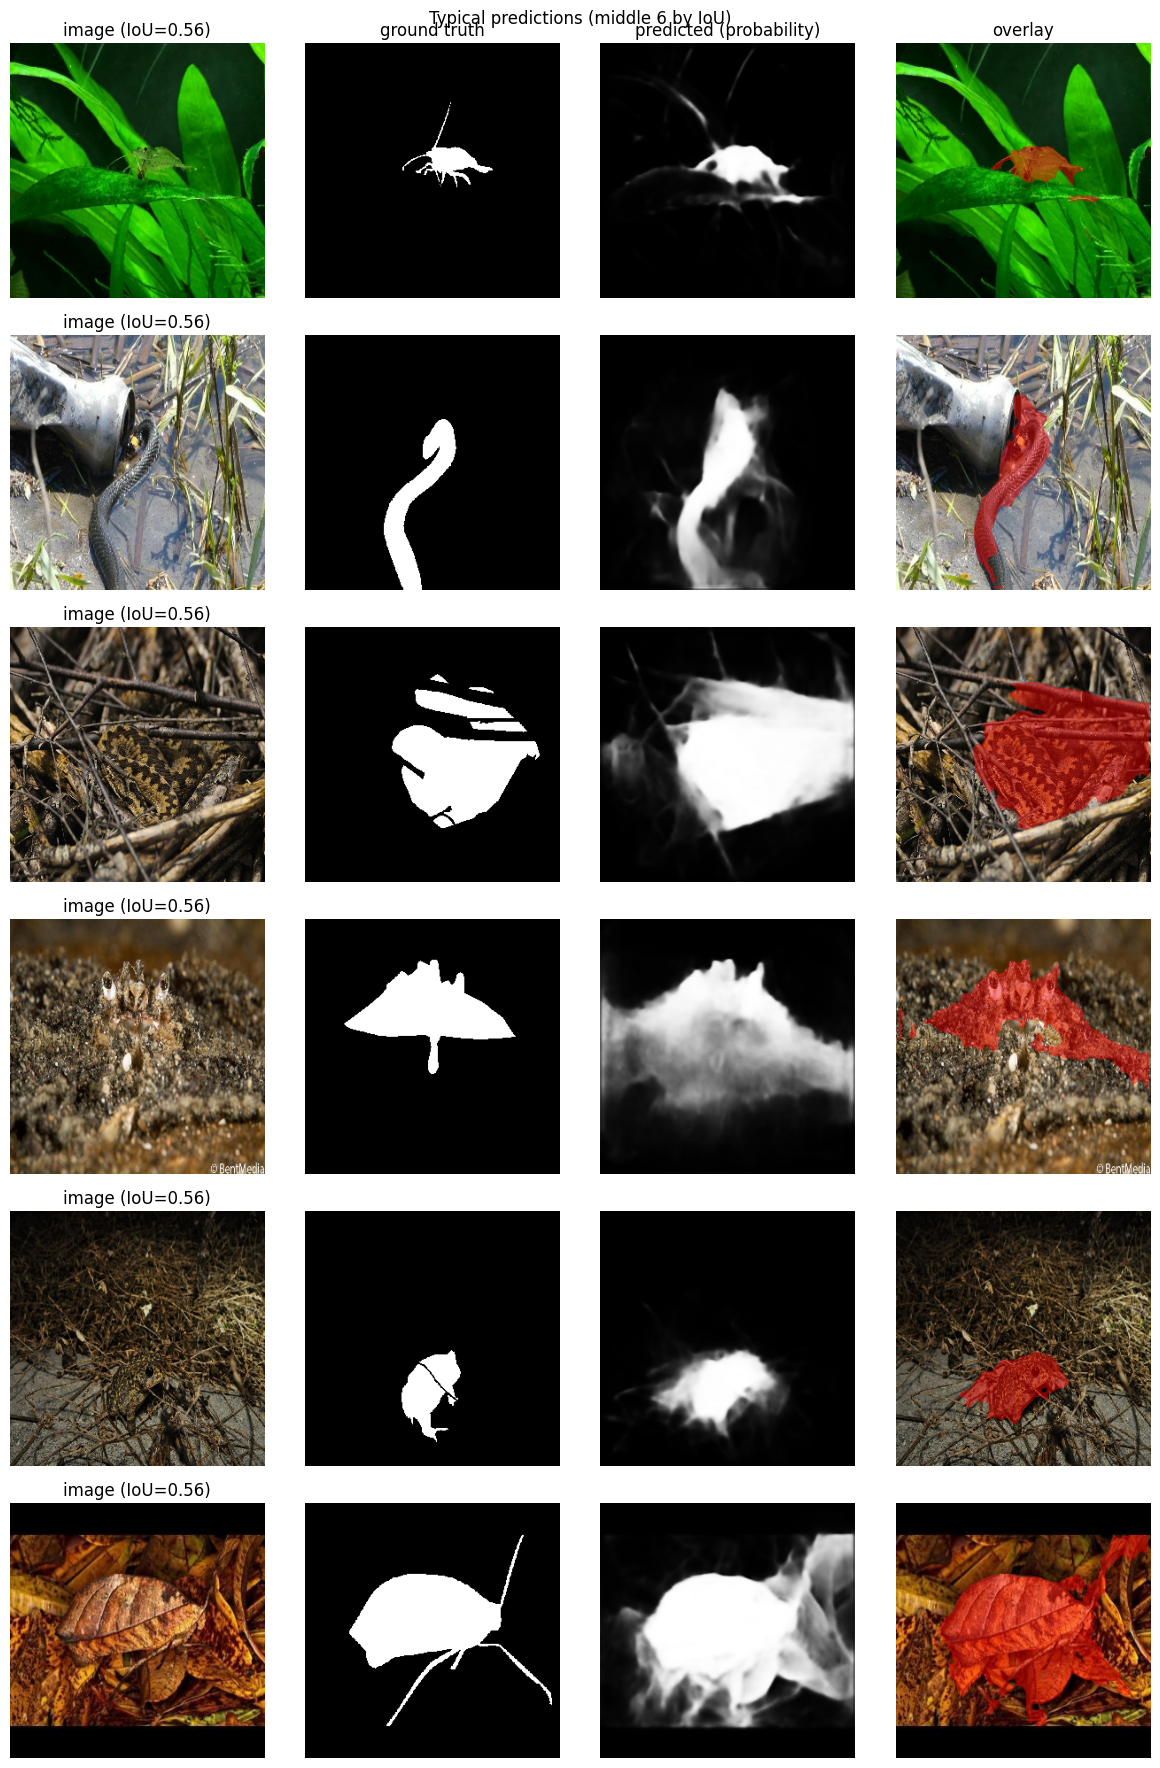

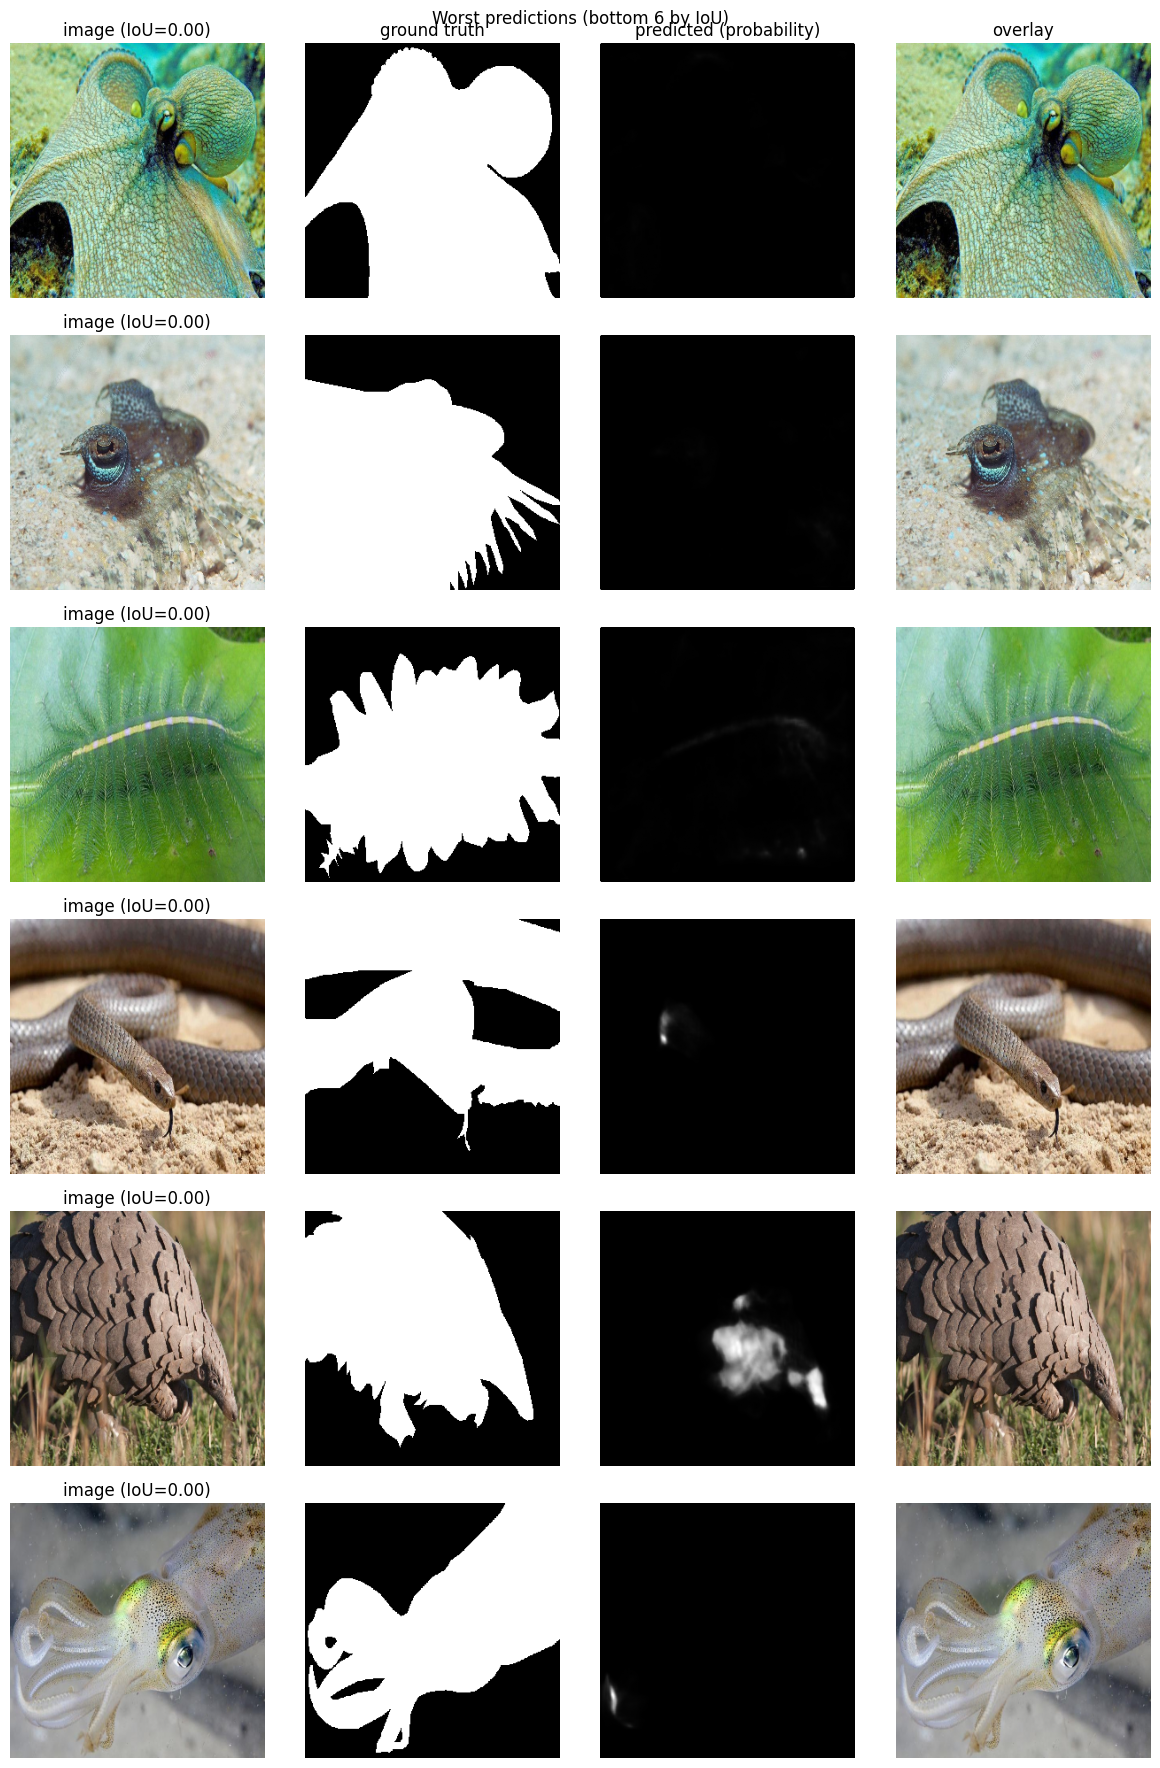

In [ ]:
N_QUALITATIVE = 6  # examples per row-group below; raise this if you want an even bigger grid


@torch.no_grad()
def predict_mask(model, img_path):
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    augmented = eval_transform(image=image, mask=np.zeros(image.shape[:2], dtype="float32"))
    x = augmented["image"].unsqueeze(0).to(DEVICE)
    logits = predict_logits(model, x)  # same TTA setting used everywhere else at evaluation time
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    return image, prob


def iou_score(pred_mask, gt_mask, threshold=0.5, eps=1e-7):
    pred_bin = (pred_mask > threshold).astype("float32")
    gt_bin = (gt_mask > 0.5).astype("float32")
    inter = (pred_bin * gt_bin).sum()
    union = pred_bin.sum() + gt_bin.sum() - inter
    return (inter + eps) / (union + eps)


def make_overlay(image_resized, pred, threshold, alpha=0.45):
    pred_bin = (pred > threshold).astype(float)
    base = image_resized.astype(float) / 250
    red_layer = np.zeros_like(base)
    red_layer[..., 0] = 1.0
    overlay = base * (1 - alpha * pred_bin[..., None]) + red_layer * (alpha * pred_bin[..., None])
    return np.clip(overlay, 0, 1)


scored = []
for img_path, mask_path in all_test_pairs:
    gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_resized = cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    gt_norm = (gt_resized > 127).astype("float32")
    _, pred = predict_mask(best_model, img_path)
    score = iou_score(pred, gt_norm, best_threshold)
    scored.append((score, img_path, mask_path))

scored.sort(key=lambda t: t[0])
worst = scored[:N_QUALITATIVE]
best = scored[-N_QUALITATIVE:][::-1]  # highest IoU first
mid = len(scored) // 2 - N_QUALITATIVE // 2
typical = scored[mid: mid + N_QUALITATIVE]


def show_examples(examples, title):
    fig, axes = plt.subplots(len(examples), 4, figsize=(12, 3 * len(examples)))
    if len(examples) == 1:
        axes = axes[None, :]
    col_titles = ["image", "ground truth", "predicted (probability)", "overlay"]
    for row, (score, img_path, mask_path) in enumerate(examples):
        image, pred = predict_mask(best_model, img_path)
        gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        image_resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        gt_resized = cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        overlay = make_overlay(image_resized, pred, best_threshold)

        panels = [image_resized, gt_resized, pred, overlay]
        cmaps = [None, "gray", "gray", None]
        for col, (panel, cmap) in enumerate(zip(panels, cmaps)):
            axes[row, col].imshow(panel, cmap=cmap)
            axes[row, col].axis("off")
        axes[row, 0].set_title(f"image (IoU={score:.2f})")
        if row == 0:
            for col in range(1, 4):
                axes[row, col].set_title(col_titles[col])
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples(best, f"Best predictions (top {N_QUALITATIVE} by IoU)")
show_examples(typical, f"Typical predictions (middle {N_QUALITATIVE} by IoU)")
show_examples(worst, f"Worst predictions (bottom {N_QUALITATIVE} by IoU)")


Correlation between object coverage and IoU: 0.305


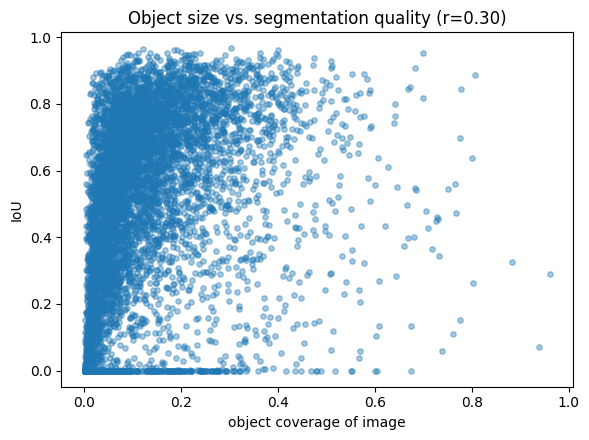

In [23]:
# Does difficulty correlate with how much of the image the object covers?
coverage_vs_iou = []
for score, img_path, mask_path in scored:
    gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    cov = (gt > 127).mean()
    coverage_vs_iou.append((cov, score))

cov_arr, iou_arr = zip(*coverage_vs_iou)
correlation = np.corrcoef(cov_arr, iou_arr)[0, 1]
print(f"Correlation between object coverage and IoU: {correlation:.3f}")

plt.figure(figsize=(6, 4.5))
plt.scatter(cov_arr, iou_arr, alpha=0.4, s=15)
plt.xlabel("object coverage of image")
plt.ylabel("IoU")
plt.title(f"Object size vs. segmentation quality (r={correlation:.2f})")
plt.tight_layout()
plt.show()
